In [3]:
pip install xgboost shap --timeout 300

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 1.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 4.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 MB 586.3 kB/s eta 0:00:0000:0100:04
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 3.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 1.8 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install shap --upgrade --timeout 300

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report
import shap
import warnings
warnings.filterwarnings('ignore')

# Rebuild dataset - binary CN vs AD only
fs = pd.read_csv('../data/OASIS3_Freesurfer_output.csv')
demo = pd.read_csv('../data/OASIS3_demographics.csv')
cdr = pd.read_csv('../data/OASIS3_UDSb4_cdr.csv')

cdr_max = cdr.groupby('OASISID')['CDRTOT'].max().reset_index()
cdr_max.columns = ['OASISID', 'max_CDR']
cdr_max['diagnosis_group'] = cdr_max['max_CDR'].apply(
    lambda x: 'CN' if x==0 else ('MCI' if x==0.5 else 'AD'))

fs_first = fs.sort_values('MR_session').groupby('Subject').first().reset_index()
fs_first = fs_first.rename(columns={'Subject': 'OASISID'})

df = demo.merge(cdr_max, on='OASISID')
df = df.merge(fs_first[['OASISID', 'TOTAL_HIPPOCAMPUS_VOLUME',
                          'lh_entorhinal_thickness', 'rh_entorhinal_thickness',
                          'lh_precuneus_thickness', 'rh_precuneus_thickness',
                          'lh_precuneus_volume', 'rh_precuneus_volume',
                          'Left-Amygdala_volume', 'Right-Amygdala_volume',
                          'IntraCranialVol', 'FS QC Status']], on='OASISID')
df = df[df['FS QC Status'] == 'Passed']

# ICV corrections
df['hippo_ICV'] = (df['TOTAL_HIPPOCAMPUS_VOLUME'] / df['IntraCranialVol']) * 100
df['mean_entorhinal'] = (df['lh_entorhinal_thickness'] + df['rh_entorhinal_thickness']) / 2
df['mean_precuneus'] = (df['lh_precuneus_thickness'] + df['rh_precuneus_thickness']) / 2
df['amygdala_ICV'] = ((df['Left-Amygdala_volume'] + df['Right-Amygdala_volume']) / 
                       df['IntraCranialVol']) * 100

# CN vs AD only
df_binary = df[df['diagnosis_group'].isin(['CN', 'AD'])].copy()
df_binary['label'] = (df_binary['diagnosis_group'] == 'AD').astype(int)

features = ['hippo_ICV', 'mean_entorhinal', 'mean_precuneus', 
            'amygdala_ICV', 'AgeatEntry', 'GENDER']

X = df_binary[features].dropna()
y = df_binary.loc[X.index, 'label']

print("Dataset:", X.shape)
print("Class distribution:", y.value_counts().to_dict())

/home/kabir/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset: (756, 6)
Class distribution: {0: 595, 1: 161}


In [5]:
# Cross-validated model comparison
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(scale_pos_weight=595/161, random_state=42, verbosity=0)
}

print("5-Fold Cross-Validation Results (ROC-AUC):")
print("=" * 45)

results = {}
for name, model in models.items():
    if name == 'XGBoost':
        scores = cross_val_score(model, X, y, cv=skf, scoring='roc_auc')
    else:
        scores = cross_val_score(model, X_scaled, y, cv=skf, scoring='roc_auc')
    results[name] = scores
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")

5-Fold Cross-Validation Results (ROC-AUC):
Logistic Regression: 0.896 ± 0.023
Random Forest: 0.874 ± 0.030
XGBoost: 0.861 ± 0.032


In [6]:
# Train final XGBoost on full data and explain with SHAP
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

final_model = XGBClassifier(scale_pos_weight=595/161, random_state=42, verbosity=0)
final_model.fit(X_train, y_train)

# SHAP values
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
plt.sca(axes[0])
shap.summary_plot(shap_values, X_test, feature_names=features, 
                  plot_type='bar', show=False)
axes[0].set_title('Mean |SHAP| Feature Importance')

# SHAP dot plot
plt.sca(axes[1])
shap.summary_plot(shap_values, X_test, feature_names=features, show=False)
axes[1].set_title('SHAP Value Distribution')

plt.tight_layout()
plt.savefig('../results/03_shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Test set AUC
from sklearn.metrics import roc_auc_score
y_pred_proba = final_model.predict_proba(X_test)[:, 1]
print(f"Test set AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

ValueError: could not convert string to float: '[5.009137E-1]'

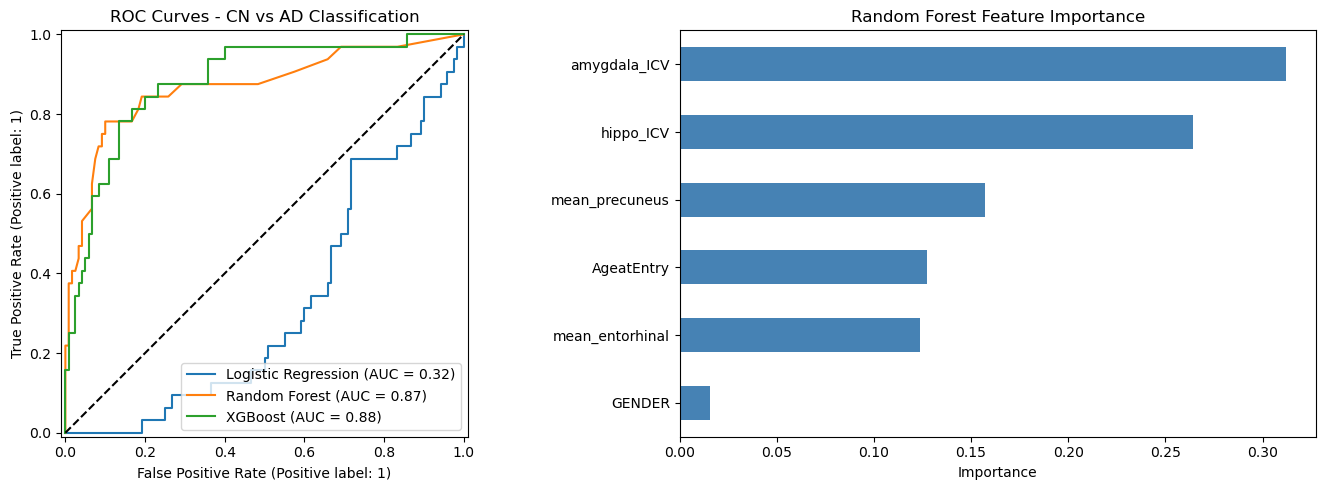

Test AUCs:
  Logistic Regression: 0.319
  Random Forest: 0.869
  XGBoost: 0.881


In [8]:
# Skip SHAP due to version conflict - use Random Forest feature importance instead
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, RocCurveDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Train all three models
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
xgb = XGBClassifier(scale_pos_weight=595/161, random_state=42, verbosity=0)

lr.fit(X_scaled[:len(X_train)], y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, model, X_t in [('Logistic Regression', lr, scaler.transform(X_test)),
                           ('Random Forest', rf, X_test),
                           ('XGBoost', xgb, X_test)]:
    RocCurveDisplay.from_estimator(model, X_t, y_test, ax=axes[0], name=name)

axes[0].set_title('ROC Curves - CN vs AD Classification')
axes[0].plot([0,1],[0,1],'k--')

# Random Forest feature importance
importances = pd.Series(rf.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Random Forest Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../results/03_classification_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Test AUCs:")
for name, model, X_t in [('Logistic Regression', lr, scaler.transform(X_test)),
                           ('Random Forest', rf, X_test),
                           ('XGBoost', xgb, X_test)]:
    auc = roc_auc_score(y_test, model.predict_proba(X_t)[:,1])
    print(f"  {name}: {auc:.3f}")